Task 3 - Data Analysis/ Visualization

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt


In [ ]:
!cp /var/sales.csv.csv .


cp: cannot stat '/var/sales.csv.csv': No such file or directory


In [ ]:
!cp /var/sales.csv.csv .


cp: cannot stat '/var/sales.csv.csv': No such file or directory


In [ ]:
import os
os.listdir()


['.config', 'sample_data']

In [ ]:
['sales.csv.csv', 'something_else.ipynb']


['sales.csv.csv', 'something_else.ipynb']

In [6]:
import os
os.listdir("/content")


['.config', 'sample_data']

In [7]:
!cp /sales.csv.csv /content/



In [8]:
!cp /workspace/sales.csv.csv /content/


cp: cannot stat '/workspace/sales.csv.csv': No such file or directory


In [9]:
import os
os.listdir("/content")


['.config', 'sales.csv.csv', 'sample_data']

In [10]:
import pandas as pd

df = pd.read_csv("/content/sales.csv.csv")
df.head()


,Unnamed: 0,Date,Weekly_Sales
0,NaN,05-02-2010,24924.50
1,NaN,05-02-2010,11737.12
2,NaN,05-02-2010,13223.76
3,NaN,05-02-2010,37.44
4,NaN,05-02-2010,1085.29


In [11]:
df.columns


Index(['Unnamed: 0', 'Date', 'Weekly_Sales'], dtype='object')

In [13]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report


In [14]:
df = pd.read_csv("/content/sales.csv.csv")
df.head()


,Unnamed: 0,Date,Weekly_Sales
0,NaN,05-02-2010,24924.50
1,NaN,05-02-2010,11737.12
2,NaN,05-02-2010,13223.76
3,NaN,05-02-2010,37.44
4,NaN,05-02-2010,1085.29


In [15]:
df = df.drop("Unnamed: 0", axis=1)


In [17]:
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")


In [18]:
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

df["Day"] = df["Date"].dt.day
df["Month"] = df["Date"].dt.month
df["Year"] = df["Date"].dt.year

df = df.drop("Date", axis=1)


In [20]:
median_sales = df["Weekly_Sales"].median()

df["Sales_Level"] = df["Weekly_Sales"].apply(
    lambda x: 1 if x >= median_sales else 0
)


In [21]:
X = df.drop("Sales_Level", axis=1)
y = df["Sales_Level"]


In [22]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [23]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)


DecisionTreeClassifier(random_state=42)

In [24]:
y_pred = model.predict(X_test)


In [ ]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))


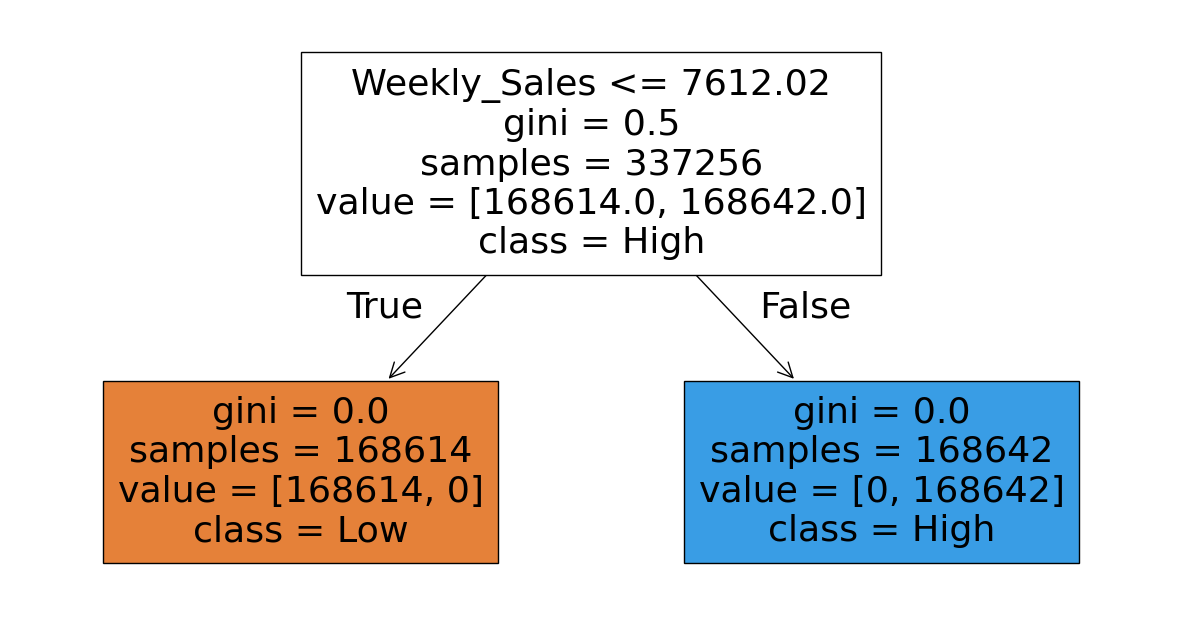

In [25]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(15,8))
plot_tree(model, feature_names=X.columns, class_names=["Low", "High"], filled=True)
plt.show()
